In [1]:
!pip install "dacite~=1.6.0" mlflow dagshub scikit-learn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 77.1 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 65.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import mlflow
import mlflow.sklearn
import dagshub
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.pipeline import Pipeline

RANDOM_STATE    = 42
REPO_OWNER      = 'ejoba22'
REPO_NAME       = 'IEEE-CIS-Fraud-Detection'
EXPERIMENT_NAME = 'DecisionTree_Training'

dagshub.init(repo_owner=REPO_OWNER, repo_name=REPO_NAME, mlflow=True)

if mlflow.active_run() is not None:
    mlflow.end_run()

experiment    = mlflow.set_experiment(EXPERIMENT_NAME)
EXPERIMENT_ID = experiment.experiment_id

print('MLflow tracking URI:', mlflow.get_tracking_uri())
print('MLflow experiment:',   experiment.name)
print('MLflow experiment id:', EXPERIMENT_ID)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=235deebf-8594-4328-b30a-9926802cf95c&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=1caa1fed3004c92b9a8784261ff8fd4a2de5b54a26ca7fecea44abd252c3c236




Accessing as ejoba22

Initialized MLflow to track repo "ejoba22/IEEE-CIS-Fraud-Detection"

Repository ejoba22/IEEE-CIS-Fraud-Detection initialized!

2026/05/05 17:45:29 INFO mlflow.tracking.fluent: Experiment with name 'DecisionTree_Training' does not exist. Creating a new experiment.


MLflow tracking URI: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow
MLflow experiment: DecisionTree_Training
MLflow experiment id: 4


In [3]:
def reduce_mem_usage(df):
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        if col_type == object:
            continue
        c_min = df[col].min()
        c_max = df[col].max()
        if str(col_type).startswith('int'):
            if c_min >= np.iinfo(np.int8).min and c_max <= np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif c_min >= np.iinfo(np.int16).min and c_max <= np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif c_min >= np.iinfo(np.int32).min and c_max <= np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
        elif str(col_type).startswith('float'):
            df[col] = df[col].astype(np.float32)
    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f'Memory reduced from {start_mem:.1f} MB to {end_mem:.1f} MB')
    return df


from pathlib import Path

DATA_DIR_CANDIDATES = [
    Path('/kaggle/input/competitions/ieee-fraud-detection'),
    Path('/kaggle/input/ieee-fraud-detection')
]

DATA_DIR = next(
    (path for path in DATA_DIR_CANDIDATES if (path / 'train_transaction.csv').exists()),
    None
)

if DATA_DIR is None:
    raise FileNotFoundError(
        'Could not find IEEE-CIS data. '
        f'Tried: {[str(path) for path in DATA_DIR_CANDIDATES]}'
    )

print('Using data directory:', DATA_DIR)

train_transaction = reduce_mem_usage(pd.read_csv(DATA_DIR / 'train_transaction.csv'))
train_identity    = reduce_mem_usage(pd.read_csv(DATA_DIR / 'train_identity.csv'))

train = train_transaction.merge(train_identity, on='TransactionID', how='left')
train = reduce_mem_usage(train)
print('Raw shape:', train.shape)

Using data directory: /kaggle/input/competitions/ieee-fraud-detection
Memory reduced from 2062.1 MB to 1203.2 MB
Memory reduced from 143.1 MB to 129.9 MB
Memory reduced from 1603.3 MB to 1603.3 MB
Raw shape: (590540, 434)


# Cleaning

In [4]:
train = train.sort_values('TransactionDT').reset_index(drop=True)
split_idx  = int(len(train) * 0.8)
df_tr_raw  = train.iloc[:split_idx].copy()
df_val_raw = train.iloc[split_idx:].copy()

df_tr  = df_tr_raw.copy()
df_val = df_val_raw.copy()

print(f'Train: {len(df_tr):,} rows  |  Val: {len(df_val):,} rows')

DT_MISSING_THRESHOLD = 0.9
missing   = df_tr.isnull().mean()  
drop_cols = missing[missing > DT_MISSING_THRESHOLD].index.tolist()
drop_cols += ['TransactionID', 'TransactionDT']

df_tr  = df_tr.drop(columns=drop_cols,  errors='ignore')
df_val = df_val.drop(columns=drop_cols, errors='ignore')

cat_cols      = df_tr.select_dtypes('object').columns.tolist()
category_maps = {}
for col in cat_cols:
    df_tr[col]  = df_tr[col].fillna('missing').astype(str)
    df_val[col] = df_val[col].fillna('missing').astype(str)
    unique_vals = df_tr[col].unique()
    category_maps[col] = {v: i for i, v in enumerate(unique_vals)}
    df_tr[col]  = df_tr[col].map(category_maps[col])
    df_val[col] = df_val[col].map(category_maps[col]).fillna(-1).astype('float32')

num_cols = [c for c in df_tr.select_dtypes(include=np.number).columns if c != 'isFraud']
medians  = df_tr[num_cols].median()
df_tr[num_cols]  = df_tr[num_cols].fillna(medians)
df_val[num_cols] = df_val[num_cols].fillna(medians)

with mlflow.start_run(experiment_id=EXPERIMENT_ID, run_name='DecisionTree_Cleaning'):
    mlflow.log_param('missing_threshold', DT_MISSING_THRESHOLD)
    mlflow.log_param('imputation',        'median')
    mlflow.log_param('cat_encoding',      'ordinal (unseen=-1)')
    mlflow.log_param('dropped_cols',      len(drop_cols))
    mlflow.log_param('remaining_cols',    df_tr.shape[1])

print(f'Shape after cleaning: {df_tr.shape}')
print(f'Remaining NaNs: {df_tr.isnull().sum().sum()}')

Train: 472,432 rows  |  Val: 118,108 rows
🏃 View run DecisionTree_Cleaning at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/4/runs/fe670eeabad54eb1a5c77f708760d19d
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/4
Shape after cleaning: (472432, 420)
Remaining NaNs: 0


# Feature Engineering

In [5]:
def add_dt_features(df_feat, df_raw, feature_set='baseline'):
    df_feat = df_feat.copy()

    if feature_set == 'baseline':
        return df_feat

    if feature_set in ('time_amount', 'time_amount_interact'):
        df_feat['TransactionAmt_log'] = np.log1p(df_raw['TransactionAmt'])
        dt = df_raw['TransactionDT']
        df_feat['Transaction_hour']    = (dt // 3600) % 24
        df_feat['Transaction_weekday'] = (dt // 86400) % 7
        df_feat['is_night_hour']       = df_feat['Transaction_hour'].between(1, 6).astype(np.int8)
        df_feat['amt_rounded']         = (df_raw['TransactionAmt'] % 1 == 0).astype(np.int8)

    if feature_set == 'time_amount_interact':
        df_feat['amt_x_hour'] = df_feat['TransactionAmt_log'] * df_feat['Transaction_hour']
        if 'D1' in df_feat.columns:
            df_feat['D1_na'] = df_feat['D1'].isna().astype(np.int8)

    return df_feat


PROBE_PARAMS = dict(
    max_depth=10, class_weight='balanced',
    random_state=RANDOM_STATE
)

feature_results = {}

for feature_set in ['baseline', 'time_amount', 'time_amount_interact']:
    with mlflow.start_run(experiment_id=EXPERIMENT_ID,
                          run_name=f'DecisionTree_Feature_Engineering_{feature_set}'):
        df_tr_fe  = add_dt_features(df_tr,  df_tr_raw,  feature_set)
        df_val_fe = add_dt_features(df_val, df_val_raw, feature_set)

        X_probe_tr  = df_tr_fe.drop(columns=['isFraud'])
        y_probe_tr  = df_tr_fe['isFraud']
        X_probe_val = df_val_fe.drop(columns=['isFraud'])
        y_probe_val = df_val_fe['isFraud']

        probe = DecisionTreeClassifier(**PROBE_PARAMS)
        probe.fit(X_probe_tr, y_probe_tr)

        train_auc = roc_auc_score(y_probe_tr,  probe.predict_proba(X_probe_tr)[:, 1])
        val_auc   = roc_auc_score(y_probe_val, probe.predict_proba(X_probe_val)[:, 1])

        mlflow.log_param('feature_set',  feature_set)
        mlflow.log_param('n_features',   X_probe_tr.shape[1])
        mlflow.log_metric('train_auc',   round(train_auc, 4))
        mlflow.log_metric('val_auc',     round(val_auc,   4))
        mlflow.log_metric('overfit_gap', round(train_auc - val_auc, 4))

        feature_results[feature_set] = val_auc
        print(f'[{feature_set}]  features={X_probe_tr.shape[1]}'
              f'  train={train_auc:.4f}  val={val_auc:.4f}')

BEST_FEATURE_SET = max(feature_results, key=feature_results.get)
print(f'\nBest feature set: {BEST_FEATURE_SET}')

df_tr  = add_dt_features(df_tr,  df_tr_raw,  BEST_FEATURE_SET)
df_val = add_dt_features(df_val, df_val_raw, BEST_FEATURE_SET)
print(f'Shape after feature engineering: {df_tr.shape}')

[baseline]  features=419  train=0.8953  val=0.8142
🏃 View run DecisionTree_Feature_Engineering_baseline at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/4/runs/044e71ca67bd4ca4b23b5cf36926d4d5
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/4
[time_amount]  features=424  train=0.8953  val=0.8138
🏃 View run DecisionTree_Feature_Engineering_time_amount at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/4/runs/d2b420e303c9420ab780b19f430bba13
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/4
[time_amount_interact]  features=426  train=0.8953  val=0.8140
🏃 View run DecisionTree_Feature_Engineering_time_amount_interact at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/4/runs/11c21c0dfe6c4bbc99af8bab31988a11
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/4

Best feat

# Feature Selection

In [6]:
X_tr_base  = df_tr.drop(columns=['isFraud'])
y_tr       = df_tr['isFraud']
X_val_base = df_val.drop(columns=['isFraud'])
y_val      = df_val['isFraud']

low_var    = X_tr_base.var()[X_tr_base.var() < 0.01].index.tolist()
X_tr_novar  = X_tr_base.drop(columns=low_var)
X_val_novar = X_val_base.drop(columns=low_var)

probe_model = DecisionTreeClassifier(max_depth=10, class_weight='balanced',
                                     random_state=RANDOM_STATE)
probe_model.fit(X_tr_novar, y_tr)
importances = pd.Series(probe_model.feature_importances_, index=X_tr_novar.columns)

selection_configs = [
    ('all_features',     X_tr_base,  X_val_base),
    ('variance_only',    X_tr_novar, X_val_novar),
    ('importance_10pct', X_tr_novar.drop(columns=importances[importances <= importances.quantile(0.10)].index),
                         X_val_novar.drop(columns=importances[importances <= importances.quantile(0.10)].index)),
    ('importance_20pct', X_tr_novar.drop(columns=importances[importances <= importances.quantile(0.20)].index),
                         X_val_novar.drop(columns=importances[importances <= importances.quantile(0.20)].index)),
]

selection_results = {}

for sel_name, X_sel_tr, X_sel_val in selection_configs:
    with mlflow.start_run(experiment_id=EXPERIMENT_ID,
                          run_name=f'DecisionTree_Feature_Selection_{sel_name}'):
        eval_model = DecisionTreeClassifier(max_depth=10, class_weight='balanced',
                                            random_state=RANDOM_STATE)
        eval_model.fit(X_sel_tr, y_tr)

        train_auc = roc_auc_score(y_tr,  eval_model.predict_proba(X_sel_tr)[:, 1])
        val_auc   = roc_auc_score(y_val, eval_model.predict_proba(X_sel_val)[:, 1])

        mlflow.log_param('selection_method', sel_name)
        mlflow.log_param('low_var_dropped',  len(low_var))
        mlflow.log_param('n_features',       X_sel_tr.shape[1])
        mlflow.log_metric('train_auc',       round(train_auc, 4))
        mlflow.log_metric('val_auc',         round(val_auc,   4))
        mlflow.log_metric('overfit_gap',     round(train_auc - val_auc, 4))

        selection_results[sel_name] = (val_auc, X_sel_tr, X_sel_val)
        print(f'[{sel_name}]  features={X_sel_tr.shape[1]}'
              f'  train={train_auc:.4f}  val={val_auc:.4f}')

BEST_SELECTION = max(selection_results, key=lambda k: selection_results[k][0])
X_tr  = selection_results[BEST_SELECTION][1]
X_val = selection_results[BEST_SELECTION][2]

print(f'\nBest selection: {BEST_SELECTION}')
print(f'Final feature count: {X_tr.shape[1]}')

[all_features]  features=419  train=0.8953  val=0.8142
🏃 View run DecisionTree_Feature_Selection_all_features at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/4/runs/154289e62830439195aedb080940e262
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/4
[variance_only]  features=394  train=0.8953  val=0.8142
🏃 View run DecisionTree_Feature_Selection_variance_only at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/4/runs/f964d53c22214b43a2d42b9e3742ee2b
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/4
[importance_10pct]  features=163  train=0.8953  val=0.8138
🏃 View run DecisionTree_Feature_Selection_importance_10pct at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/4/runs/0741b93b9270482bbba2414928e54be7
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/4
[importance_

# Training

In [7]:
# Underfit: very shallow tree 
with mlflow.start_run(experiment_id=EXPERIMENT_ID, run_name='DecisionTree_Training_underfit_depth2'):
    model = DecisionTreeClassifier(
        max_depth=2,
        class_weight='balanced',
        random_state=RANDOM_STATE
    )
    model.fit(X_tr, y_tr)

    train_auc = roc_auc_score(y_tr,  model.predict_proba(X_tr)[:, 1])
    val_auc   = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

    mlflow.log_param('max_depth',    2)
    mlflow.log_param('class_weight', 'balanced')
    mlflow.log_param('note',         'intentional underfit — depth too shallow')
    mlflow.log_metric('train_auc',   round(train_auc, 4))
    mlflow.log_metric('val_auc',     round(val_auc,   4))
    mlflow.log_metric('overfit_gap', round(train_auc - val_auc, 4))

    print(f'[Underfit depth=2]  train={train_auc:.4f}  val={val_auc:.4f}  gap={train_auc-val_auc:.4f}')

[Underfit depth=2]  train=0.7166  val=0.7161  gap=0.0005
🏃 View run DecisionTree_Training_underfit_depth2 at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/4/runs/858a05a20adc4400a5de829fb0fca107
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/4


In [8]:
# Overfit
with mlflow.start_run(experiment_id=EXPERIMENT_ID, run_name='DecisionTree_Training_overfit_depth_none'):
    model = DecisionTreeClassifier(
        max_depth=None,
        min_samples_leaf=1,
        class_weight='balanced',
        random_state=RANDOM_STATE
    )
    model.fit(X_tr, y_tr)

    train_auc = roc_auc_score(y_tr,  model.predict_proba(X_tr)[:, 1])
    val_auc   = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

    mlflow.log_param('max_depth',        'None')
    mlflow.log_param('min_samples_leaf', 1)
    mlflow.log_param('class_weight',     'balanced')
    mlflow.log_param('note',             'intentional overfit — unlimited depth, min_samples_leaf=1')
    mlflow.log_metric('train_auc',       round(train_auc, 4))
    mlflow.log_metric('val_auc',         round(val_auc,   4))
    mlflow.log_metric('overfit_gap',     round(train_auc - val_auc, 4))

    print(f'[Overfit depth=None]  train={train_auc:.4f}  val={val_auc:.4f}  gap={train_auc-val_auc:.4f}')

[Overfit depth=None]  train=1.0000  val=0.6513  gap=0.3487
🏃 View run DecisionTree_Training_overfit_depth_none at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/4/runs/a2fe3b71569d498281d86caaaa32fd86
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/4


In [9]:
#Tuned

best_val_auc     = 0
best_depth       = None
best_min_leaf    = None

for max_depth in [5, 10, 15, 20]:
    for min_samples_leaf in [10, 50, 200]:
        run_name = f'DecisionTree_Training_depth{max_depth}_leaf{min_samples_leaf}'
        with mlflow.start_run(experiment_id=EXPERIMENT_ID, run_name=run_name):
            model = DecisionTreeClassifier(
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                class_weight='balanced',
                random_state=RANDOM_STATE
            )
            model.fit(X_tr, y_tr)

            train_auc = roc_auc_score(y_tr,  model.predict_proba(X_tr)[:, 1])
            val_auc   = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

            mlflow.log_param('max_depth',        max_depth)
            mlflow.log_param('min_samples_leaf', min_samples_leaf)
            mlflow.log_param('class_weight',     'balanced')
            mlflow.log_metric('train_auc',       round(train_auc, 4))
            mlflow.log_metric('val_auc',         round(val_auc,   4))
            mlflow.log_metric('overfit_gap',     round(train_auc - val_auc, 4))

            print(f'[depth={max_depth} leaf={min_samples_leaf}]  '
                  f'train={train_auc:.4f}  val={val_auc:.4f}  gap={train_auc-val_auc:.4f}')

            if val_auc > best_val_auc:
                best_val_auc  = val_auc
                best_depth    = max_depth
                best_min_leaf = min_samples_leaf

print(f'\nBest depth={best_depth}  leaf={best_min_leaf}  val_AUC={best_val_auc:.4f}')

[depth=5 leaf=10]  train=0.8170  val=0.8075  gap=0.0095
🏃 View run DecisionTree_Training_depth5_leaf10 at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/4/runs/c49750f10ce94786bfe9968e227fe759
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/4
[depth=5 leaf=50]  train=0.8169  val=0.8075  gap=0.0095
🏃 View run DecisionTree_Training_depth5_leaf50 at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/4/runs/04b0cdacfad04f98875dcd255f472909
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/4
[depth=5 leaf=200]  train=0.8169  val=0.8061  gap=0.0108
🏃 View run DecisionTree_Training_depth5_leaf200 at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/4/runs/486bceadac484a21acc28d5649d9903a
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/4
[depth=10 leaf=10]  train=0.8951  val=0.8

In [10]:
# Cross-validation with best hyperparameters

N_CV_SPLITS = 5
cv = TimeSeriesSplit(n_splits=N_CV_SPLITS)

cv_model = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_leaf=best_min_leaf,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

cv_scores = cross_val_score(
    cv_model, X_tr, y_tr,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

cv_mean = cv_scores.mean()
cv_std  = cv_scores.std()

with mlflow.start_run(experiment_id=EXPERIMENT_ID, run_name='DecisionTree_CrossValidation'):
    mlflow.log_param('cv_strategy',      'TimeSeriesSplit')
    mlflow.log_param('n_splits',         N_CV_SPLITS)
    mlflow.log_param('max_depth',        best_depth)
    mlflow.log_param('min_samples_leaf', best_min_leaf)
    mlflow.log_param('class_weight',     'balanced')
    mlflow.log_metric('cv_auc_mean',     round(cv_mean, 4))
    mlflow.log_metric('cv_auc_std',      round(cv_std,  4))
    for i, s in enumerate(cv_scores):
        mlflow.log_metric(f'cv_fold_{i+1}_auc', round(s, 4))

print(f'CV AUC ({N_CV_SPLITS}-fold TimeSeriesSplit): {cv_mean:.4f} \u00b1 {cv_std:.4f}')
print(f'Individual folds: {[round(s, 4) for s in cv_scores]}')

🏃 View run DecisionTree_CrossValidation at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/4/runs/f2d373b3eb044b4eaabf850beb26cf95
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/4
CV AUC (5-fold TimeSeriesSplit): 0.8299 ± 0.0140
Individual folds: [np.float64(0.8176), np.float64(0.8101), np.float64(0.838), np.float64(0.8352), np.float64(0.8486)]


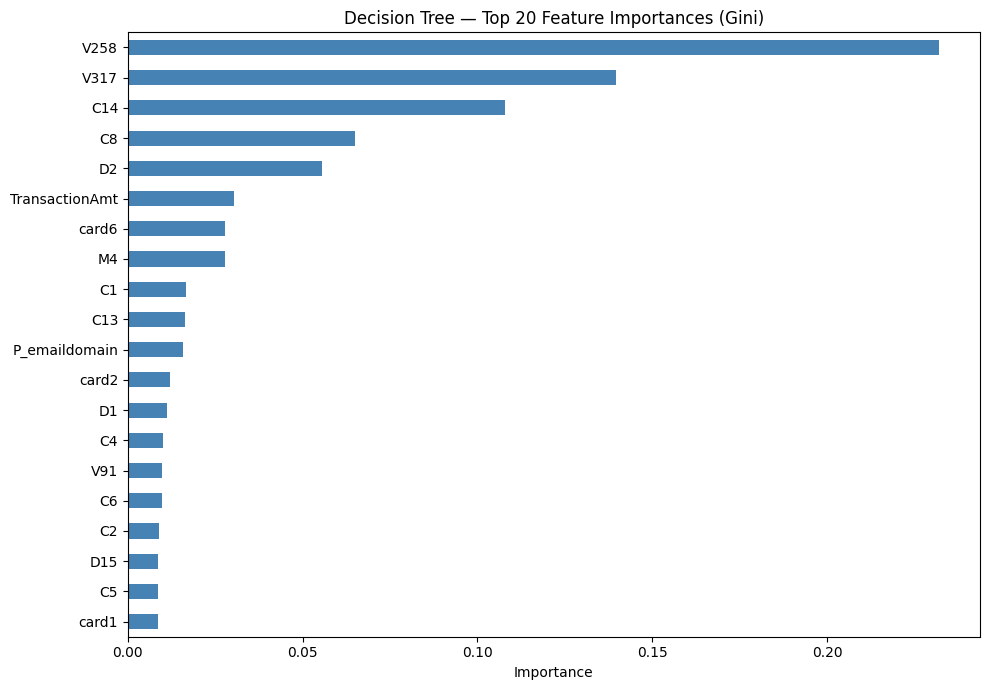

Top 10 features:
V258              0.232117
V317              0.139511
C14               0.107786
C8                0.065078
D2                0.055653
TransactionAmt    0.030253
card6             0.027836
M4                0.027815
C1                0.016622
C13               0.016422
dtype: float64


In [11]:
# Feature importance plot 
best_model = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_leaf=best_min_leaf,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
best_model.fit(X_tr, y_tr)

importances = pd.Series(best_model.feature_importances_, index=X_tr.columns)
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
top20.sort_values().plot(kind='barh', color='steelblue')
plt.title('Decision Tree \u2014 Top 20 Feature Importances (Gini)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(top20.head(10))

In [12]:
# Build and register final Pipeline 

class DecisionTreeFraudPreprocessor(BaseEstimator, TransformerMixin):
    """Full preprocessing pipeline for Decision Tree.
    Accepts raw (unprocessed) dataframe and returns a cleaned numpy array.
    Mirrors the manual preprocessing above exactly.
    """

    def __init__(self, missing_threshold=0.9, low_variance_threshold=0.01,
                 feature_set='baseline', selection_strategy='variance_only',
                 importance_quantile=0.10):
        self.missing_threshold      = missing_threshold
        self.low_variance_threshold = low_variance_threshold
        self.feature_set            = feature_set
        self.selection_strategy     = selection_strategy
        self.importance_quantile    = importance_quantile

    def _base_transform(self, X):
        d = X.drop(columns=self.drop_cols_, errors='ignore').copy()
        d = d.drop(columns=['isFraud'], errors='ignore')

        if self.feature_set in ('time_amount', 'time_amount_interact'):
            if 'TransactionAmt' in X.columns:
                d['TransactionAmt_log'] = np.log1p(X['TransactionAmt'])
                d['amt_rounded']        = (X['TransactionAmt'] % 1 == 0).astype(np.int8)
            if 'TransactionDT' in X.columns:
                dt = X['TransactionDT']
                d['Transaction_hour']    = (dt // 3600) % 24
                d['Transaction_weekday'] = (dt // 86400) % 7
                d['is_night_hour']       = d['Transaction_hour'].between(1, 6).astype(np.int8)

        if self.feature_set == 'time_amount_interact':
            if 'TransactionAmt_log' in d.columns and 'Transaction_hour' in d.columns:
                d['amt_x_hour'] = d['TransactionAmt_log'] * d['Transaction_hour']
            if 'D1' in d.columns:
                d['D1_na'] = d['D1'].isna().astype(np.int8)

        cat_cols = d.select_dtypes('object').columns.tolist()
        for col in cat_cols:
            vals = d[col].fillna('missing').astype(str)
            if hasattr(self, 'category_maps_') and col in self.category_maps_:
                d[col] = vals.map(self.category_maps_[col]).fillna(-1).astype('float32')
            else:
                d[col] = vals.map({v: i for i, v in enumerate(vals.unique())}).fillna(-1).astype('float32')

        for col in d.select_dtypes('float64').columns:
            d[col] = d[col].astype('float32')
        for col in d.select_dtypes('int64').columns:
            d[col] = d[col].astype('int32')

        return d

    def fit(self, X, y=None):
        miss = X.isnull().mean()
        self.drop_cols_ = miss[miss > self.missing_threshold].index.tolist()
        self.drop_cols_ += ['TransactionID', 'TransactionDT']

        d_raw = X.drop(columns=self.drop_cols_, errors='ignore').copy()
        self.category_maps_ = {}
        for col in d_raw.select_dtypes('object').columns:
            vals = d_raw[col].fillna('missing').astype(str)
            self.category_maps_[col] = {v: i for i, v in enumerate(vals.unique())}

        d = self._base_transform(X)

        self.medians_ = d.median(numeric_only=True)
        d = d.fillna(self.medians_)

        if self.selection_strategy != 'all_features':
            self.low_var_cols_ = d.var()[d.var() < self.low_variance_threshold].index.tolist()
        else:
            self.low_var_cols_ = []
        d = d.drop(columns=self.low_var_cols_, errors='ignore')

        if self.selection_strategy in ('importance_10pct', 'importance_20pct') and y is not None:
            probe = DecisionTreeClassifier(max_depth=10, class_weight='balanced',
                                           random_state=42)
            probe.fit(d, y)
            imp = pd.Series(probe.feature_importances_, index=d.columns)
            threshold = imp.quantile(self.importance_quantile)
            self.low_importance_cols_ = imp[imp <= threshold].index.tolist()
        else:
            self.low_importance_cols_ = []
        d = d.drop(columns=self.low_importance_cols_, errors='ignore')

        self.feature_columns_ = d.columns.tolist()
        return self

    def transform(self, X):
        d = self._base_transform(X)
        d = d.fillna(self.medians_)
        d = d.drop(columns=self.low_var_cols_,        errors='ignore')
        d = d.drop(columns=self.low_importance_cols_,  errors='ignore')
        d = d.reindex(columns=self.feature_columns_,  fill_value=0)
        return d.values


required_vars = ['best_depth', 'best_min_leaf', 'BEST_FEATURE_SET', 'BEST_SELECTION',
                 'df_tr_raw', 'df_val_raw', 'EXPERIMENT_ID']
missing_vars  = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise RuntimeError(f'Run earlier cells first. Missing: {missing_vars}')

_quantile_map = {'importance_10pct': 0.10, 'importance_20pct': 0.20}

final_pipeline = Pipeline(steps=[
    ('preprocess', DecisionTreeFraudPreprocessor(
        missing_threshold=DT_MISSING_THRESHOLD,
        low_variance_threshold=0.01,
        feature_set=BEST_FEATURE_SET,
        selection_strategy=BEST_SELECTION,
        importance_quantile=_quantile_map.get(BEST_SELECTION, 0.10)
    )),
    ('model', DecisionTreeClassifier(
        max_depth=best_depth,
        min_samples_leaf=best_min_leaf,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

with mlflow.start_run(experiment_id=EXPERIMENT_ID, run_name='DecisionTree_Final_Pipeline_Register'):
    X_train_raw = df_tr_raw.drop(columns=['isFraud'])
    y_train_raw = df_tr_raw['isFraud']
    X_val_raw   = df_val_raw.drop(columns=['isFraud'])
    y_val_raw   = df_val_raw['isFraud']

    final_pipeline.fit(X_train_raw, y_train_raw)

    pipeline_feats = final_pipeline.named_steps['preprocess'].feature_columns_
    tuning_feats   = list(X_tr.columns)
    if pipeline_feats != tuning_feats:
        import warnings as _w
        _w.warn(f'Feature mismatch: pipeline={len(pipeline_feats)} tuning={len(tuning_feats)}')
    else:
        print(f'Feature check passed: {len(pipeline_feats)} features match tuning.')

    train_auc = roc_auc_score(y_train_raw, final_pipeline.predict_proba(X_train_raw)[:, 1])
    val_auc   = roc_auc_score(y_val_raw,   final_pipeline.predict_proba(X_val_raw)[:, 1])
    gap       = train_auc - val_auc

    mlflow.log_param('max_depth',           best_depth)
    mlflow.log_param('min_samples_leaf',    best_min_leaf)
    mlflow.log_param('class_weight',        'balanced')
    mlflow.log_param('missing_threshold',   DT_MISSING_THRESHOLD)
    mlflow.log_param('imputation',          'median')
    mlflow.log_param('cat_encoding',        'ordinal (unseen=-1)')
    mlflow.log_param('feature_engineering', BEST_FEATURE_SET)
    mlflow.log_param('feature_selection',   BEST_SELECTION)
    mlflow.log_metric('train_auc',          round(train_auc, 4))
    mlflow.log_metric('val_auc',            round(val_auc,   4))
    mlflow.log_metric('overfit_gap',        round(gap,       4))

    mlflow.sklearn.log_model(
        sk_model=final_pipeline,
        artifact_path='decision_tree_pipeline',
        registered_model_name='IEEE_CIS_DecisionTree_Best'
    )

    print(f'Final pipeline — train={train_auc:.4f}  val={val_auc:.4f}  gap={gap:.4f}')
    print('Registered to Model Registry as: IEEE_CIS_DecisionTree_Best')

Feature check passed: 394 features match tuning.


2026/05/05 18:01:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/05 18:01:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'IEEE_CIS_DecisionTree_Best'.
2026/05/05 18:01:30 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: IEEE_CIS_DecisionTree_Best, version 1
Created version '1' of model 'IEEE_CIS_DecisionTree_Best'.


Final pipeline — train=0.9191  val=0.8428  gap=0.0764
Registered to Model Registry as: IEEE_CIS_DecisionTree_Best
🏃 View run DecisionTree_Final_Pipeline_Register at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/4/runs/dc1eb34189d943f58437ba069ca0a69b
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/4
